# Task 4: Model Development

This notebook trains and evaluates baseline machine learning models for the credit risk proxy target created during feature engineering.

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

project_root = Path.cwd().parent
sys.path.append(str(project_root))

from src.data_processing import load_data
from src.modeling import (
    prepare_model_data,
    split_data,
    train_logistic_regression,
    train_random_forest,
    evaluate_model,
    get_confusion_matrix,
    get_classification_report
)

In [2]:
data_path = "../data/processed/feature_engineered_data.csv"

df = load_data(data_path)

df.head()

,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProductId,Amount,Value,...,ProductCategory_ticket,ProductCategory_transport,ProductCategory_tv,ProductCategory_utility_bill,ChannelId_ChannelId_2,ChannelId_ChannelId_3,ChannelId_ChannelId_5,PricingStrategy_1,PricingStrategy_2,PricingStrategy_4
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProductId_10,1000.0,1000,...,False,False,False,False,False,True,False,False,True,False
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProductId_6,-20.0,20,...,False,False,False,False,True,False,False,False,True,False
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProductId_1,500.0,500,...,False,False,False,False,False,True,False,False,True,False
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProductId_21,20000.0,21800,...,False,False,False,True,False,True,False,False,True,False
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProductId_6,-644.0,644,...,False,False,False,False,True,False,False,False,True,False


In [3]:
df.shape

(95662, 32)

In [4]:
df["is_high_risk"].value_counts()

is_high_risk
0    84653
1    11009
Name: count, dtype: int64

## Modeling Dataset Overview

The feature-engineered dataset created in Task 3 is used for model development. The dataset contains 95,662 records and 32 engineered features after encoding categorical variables.

The target variable is `is_high_risk`, which represents the proxy credit risk label generated from RFM-based customer segmentation.

The target distribution shows a moderate class imbalance, with lower-risk customers forming the majority class. This imbalance is considered during model training and evaluation.

In [5]:
X, y = prepare_model_data(df, target_column="is_high_risk")

X.shape, y.shape

((95662, 22), (95662,))

In [6]:
X.head()

,Amount,Value,FraudResult,ProviderId_ProviderId_2,ProviderId_ProviderId_3,ProviderId_ProviderId_4,ProviderId_ProviderId_5,ProviderId_ProviderId_6,ProductCategory_data_bundles,ProductCategory_financial_services,...,ProductCategory_ticket,ProductCategory_transport,ProductCategory_tv,ProductCategory_utility_bill,ChannelId_ChannelId_2,ChannelId_ChannelId_3,ChannelId_ChannelId_5,PricingStrategy_1,PricingStrategy_2,PricingStrategy_4
0,1000.0,1000,0,False,False,False,False,True,False,False,...,False,False,False,False,False,True,False,False,True,False
1,-20.0,20,0,False,False,True,False,False,False,True,...,False,False,False,False,True,False,False,False,True,False
2,500.0,500,0,False,False,False,False,True,False,False,...,False,False,False,False,False,True,False,False,True,False
3,20000.0,21800,0,False,False,False,False,False,False,False,...,False,False,False,True,False,True,False,False,True,False
4,-644.0,644,0,False,False,True,False,False,False,True,...,False,False,False,False,True,False,False,False,True,False


In [7]:
X_train, X_test, y_train, y_test = split_data(X, y)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((76529, 22), (19133, 22), (76529,), (19133,))

## Train-Test Split

The dataset was split into training and testing sets using stratified sampling. Stratification helps preserve the target class distribution in both sets, which is important because credit risk datasets may contain class imbalance.

The final split produced:
- 76,529 training samples
- 19,133 testing samples

A total of 22 input features were used for model training.

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
logistic_model = train_logistic_regression(
    X_train_scaled,
    y_train
)

logistic_results = evaluate_model(
    logistic_model,
    X_test_scaled,
    y_test,
    "Logistic Regression"
)

logistic_results

{'model': 'Logistic Regression',
 'accuracy': 0.49594940678409033,
 'precision': 0.132747729964469,
 'recall': 0.6108083560399636,
 'f1_score': 0.21809631911788552,
 'roc_auc': 0.5642614000266402}

## Logistic Regression Model

Logistic Regression was used as a baseline model because it is simple, interpretable, and commonly used in regulated credit risk environments. Although it may be less powerful than ensemble models, its transparency makes it useful for explaining risk drivers.

The model achieved moderate performance on the proxy credit risk dataset, providing a useful benchmark for comparison with more advanced models such as Random Forest.

In [11]:
random_forest_model = train_random_forest(X_train, y_train)

random_forest_results = evaluate_model(
    random_forest_model,
    X_test,
    y_test,
    "Random Forest"
)

random_forest_results

{'model': 'Random Forest',
 'accuracy': 0.6826948204672555,
 'precision': 0.17763706048991834,
 'recall': 0.4841053587647593,
 'f1_score': 0.25990491283676703,
 'roc_auc': 0.642557283982844}

## Random Forest Model

Random Forest was trained as a more flexible machine learning model. It can capture non-linear relationships and interactions between features, but it is less interpretable than Logistic Regression.

Compared to the baseline Logistic Regression model, Random Forest achieved stronger predictive performance, particularly in overall accuracy and ROC-AUC score, making it a more effective model for identifying proxy credit risk patterns in the dataset.

In [12]:
results_df = pd.DataFrame([
    logistic_results,
    random_forest_results
])

results_df

,model,accuracy,precision,recall,f1_score,roc_auc
0,Logistic Regression,0.495949,0.132748,0.610808,0.218096,0.564261
1,Random Forest,0.682695,0.177637,0.484105,0.259905,0.642557


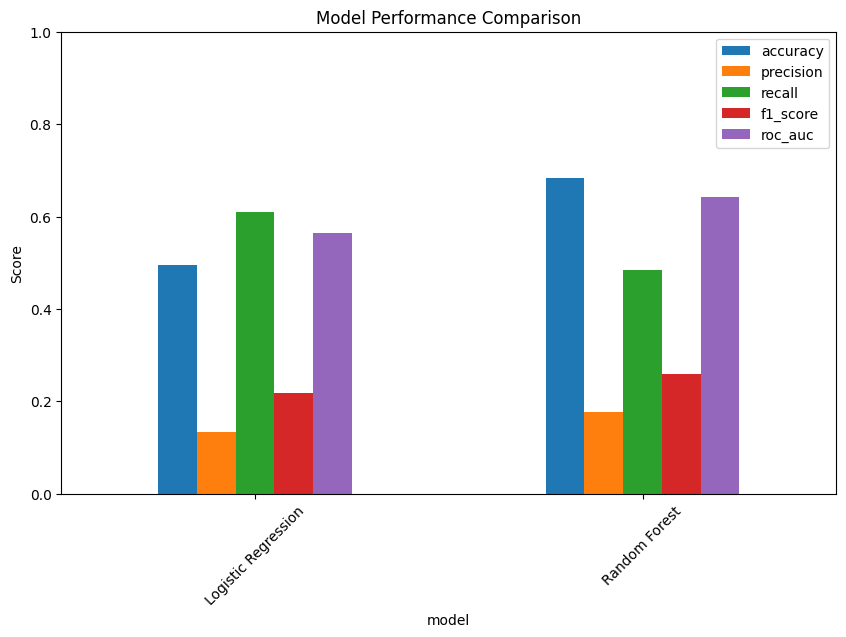

In [13]:
results_df.set_index("model")[["accuracy", "precision", "recall", "f1_score", "roc_auc"]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.show()

## Model Comparison

The models were evaluated using Accuracy, Precision, Recall, F1-score, and ROC-AUC. Since the dataset contains class imbalance, accuracy alone is not sufficient for evaluating credit risk models. Recall is particularly important because failing to identify high-risk customers may lead to financial losses. ROC-AUC and F1-score also provide additional insight into the models’ ability to distinguish between lower-risk and higher-risk customers.

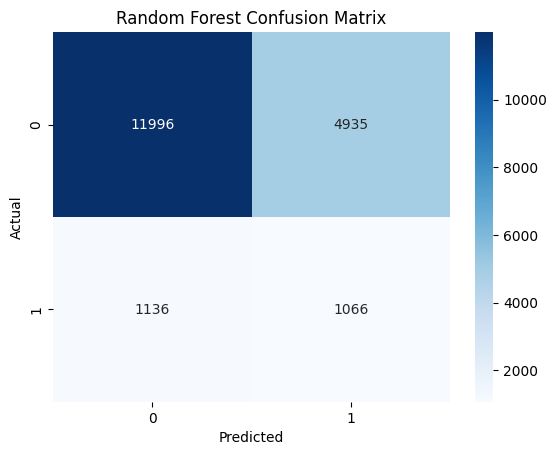

In [14]:
rf_cm = get_confusion_matrix(random_forest_model, X_test, y_test)

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [15]:
print(get_classification_report(random_forest_model, X_test, y_test))

              precision    recall  f1-score   support

           0       0.91      0.71      0.80     16931
           1       0.18      0.48      0.26      2202

    accuracy                           0.68     19133
   macro avg       0.55      0.60      0.53     19133
weighted avg       0.83      0.68      0.74     19133



## Evaluation Interpretation

In regulated financial environments, model evaluation must consider both predictive performance and business risk. Although the Random Forest model achieved better overall accuracy and ROC-AUC than Logistic Regression, its precision for identifying high-risk customers remained relatively low, meaning many lower-risk customers were incorrectly flagged as risky. Recall is also important because missing truly risky customers may lead to financial losses. Therefore, model selection should balance predictive performance, interpretability, and operational impact.